In [1]:
!pip -q install -U ultralytics onnx onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 92.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 83.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
from collections import Counter

import json
import random
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Video, display
from matplotlib.patches import Rectangle
from PIL import Image
from ultralytics import YOLO
from concurrent.futures import ThreadPoolExecutor

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
DRIVE_DATASET_ROOT = Path("/content/drive/MyDrive/Yolo_road2022_dataset/RDD2022_China_MotorBike")
DATASET_ROOT  = Path("/content/RDD2022_China_MotorBike_1")


def copy_file(src_file, src_root, dst_root):
    relative_path = src_file.relative_to(src_root)
    dest_file = dst_root / relative_path
    dest_file.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_file, dest_file)


for split in ["train", "val"]:
    src_dir = DRIVE_DATASET_ROOT / split
    dst_dir = DATASET_ROOT / split
    files = [p for p in src_dir.rglob("*") if p.is_file()]
    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = [
            executor.submit(copy_file, f, src_dir, dst_dir) for f in files
        ]
        for future in futures:
            future.result()

In [5]:
BEST_MODEL_PATH = Path(
    DRIVE_DATASET_ROOT /
    "runs/yolo26n_rdd2022_baseline" /
    "weights/best.pt"
)

DATA_YAML_PATH = Path(
    DRIVE_DATASET_ROOT / "configs" /
    "rdd2022_china_motorbike.yaml"
)

DATASET_ROOT = Path(
    "/content/"
    "RDD2022_China_MotorBike_1"
)

VAL_IMAGES_DIR = DATASET_ROOT / "val" / "images"
VAL_LABELS_DIR = DATASET_ROOT / "val" / "labels"

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/"
    "Yolo_road2022_dataset/"
    "unit_01_final_analysis"
)

required_paths = [BEST_MODEL_PATH, DATA_YAML_PATH, VAL_IMAGES_DIR, VAL_LABELS_DIR]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Path not found:\n{path}")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("Best model :", BEST_MODEL_PATH)
print("Validation :", VAL_IMAGES_DIR)
print("Output     :", OUTPUT_ROOT)

Best model : /content/drive/MyDrive/Yolo_road2022_dataset/RDD2022_China_MotorBike/runs/yolo26n_rdd2022_baseline/weights/best.pt
Validation : /content/RDD2022_China_MotorBike_1/val/images
Output     : /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis


**Load model and device**

In [6]:
DEVICE = (0 if torch.cuda.is_available() else "cpu")
model = YOLO(str(BEST_MODEL_PATH))

print("Device:", DEVICE)
print("Classes:")
for class_id, class_name in model.names.items():
    print(class_id, "→", class_name)

Device: 0
Classes:
0 → D00
1 → D10
2 → D20
3 → D40


In [7]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp"}

val_images = sorted(
    path
    for path in VAL_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_SUFFIXES
)

labels_by_stem = {
    path.stem: path for path in VAL_LABELS_DIR.glob("*.txt")
}

images_by_stem = {
    path.stem: path for path in val_images
}

print("Validation images:", len(val_images))

Validation images: 387


### Systematic Error Analysis

**YOLO label → absolute XYXY**

In [8]:
def load_ground_truth(label_path, image_width, image_height):
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return {
            "boxes" : np.empty((0, 4), dtype=np.float32),
            "classes" : np.empty((0), dtype=np.float64)
        }
    
    boxes = []
    classes = []
    
    for line in text.splitlines():
        parts = line.split()
        class_id = int(parts[0])
        
        center_x = float(parts[1])
        center_y = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])
        
        center_x *= image_width
        center_y *= image_height
        box_width *= image_width
        box_height *= image_height
        
        x1 = center_x - box_width / 2
        y1 = center_y - box_height / 2
        x2 = center_x + box_width / 2
        y2 = center_y + box_height / 2
        
        boxes.append([x1, y1, x2, y2])
        classes.append(class_id)
        
        return {
            "boxes": np.asarray(boxes, dtype=np.float32),
            "classes": np.asarray(classes,dtype=np.int64)
        }

**NumPy IoU**

In [9]:
def calculate_ious(box, candidate_boxes):
    if len(candidate_boxes) == 0:
        return np.empty((0,), dtype=np.float32)
    
    interse_x1 = np.maximum(box[0], candidate_boxes[:, 0])
    interse_y1 = np.maximum(box[1], candidate_boxes[:, 1])
    interse_x2 = np.maximum(box[2], candidate_boxes[:, 2])
    interse_y2 = np.maximum(box[3], candidate_boxes[:, 3])
    
    interse_width = np.maximum(0, interse_x2 - interse_x1)
    interse_height = np.maximum(0, interse_y2 - interse_y1)
    
    inter_area = interse_width * interse_height
    box_area = (max(0, box[2] - box[0]) * max(0, box[3] - box[1]))
    
    candidate_area = (
        np.maximum(0, candidate_boxes[:, 2] - candidate_boxes[:, 0]) * np.maximum(0, candidate_boxes[:, 3] - candidate_boxes[:, 1])
    )
    
    union_area = box_area + candidate_area - inter_area
    
    return np.divide(
        inter_area, union_area,
        out=np.zeros_like(inter_area),
        where=union_area > 0
    )

**Cache validation predictions**

In [10]:
MINIMUM_ANALYSIS_CONFIDENCE = 0.01
IMAGE_SIZE = 640
prediction_cache = []

result_generator = model.predict(
    source=str(VAL_IMAGES_DIR),
    imgsz=IMAGE_SIZE,
    conf=MINIMUM_ANALYSIS_CONFIDENCE,
    device=DEVICE,
    stream=True,
    save=False,
    verbose=False
)

In [11]:
for result in result_generator:
    image_path = Path(result.path)
    image_height, image_width = result.orig_shape
    
    ground_truth = load_ground_truth(
        labels_by_stem[image_path.stem],
        image_width, image_height
    )
    
    prediction_cache.append({
        "stem" : image_path.stem,
        "image_path" : image_path,
        "image_width": image_width,
        "image_height": image_height,
        "gt_boxes" : ground_truth["boxes"],
        "gt_classes" : ground_truth["classes"],
        "pred_boxes" : (
            result.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
        ),
        "pred_classes" : (
            result.boxes.cls.detach().cpu().numpy().astype(np.float32)
        ),
        "pred_confidences" : (
            result.boxes.conf.detach().cpu().numpy().astype(np.float32)
        )
    })


print("Cached images:", len(prediction_cache))

Cached images: 387


**One-to-one matching**

In [12]:
def match_image(item, confidence_threshold, iou_threshold=0.50):
    gt_boxes = item["gt_boxes"]
    gt_classes = item["gt_classes"]
    keep = item["pred_confidences"] >= confidence_threshold
    
    pred_boxes = item["pred_boxes"][keep]
    pred_classes = item["pred_classes"][keep]
    pred_confidences = item["pred_confidences"][keep]
    order = np.argsort(-pred_confidences)
    
    pred_boxes = pred_boxes[order]
    pred_classes = pred_classes[order]
    pred_confidences = pred_confidences[order]

    match_ground_truths = set()
    prediction_datails = []
    
    class_statistics = {
        int(class_id): {"tp": 0, "fp": 0, "fn": 0} for class_id in model.names
    }
    
    for pred_box, pred_class, confidence in zip(
        pred_boxes, pred_classes, pred_confidences
    ):
        candidate_indices = [
            index for index, gt_class in enumerate(gt_classes)
            if (int(gt_class) == int(pred_class) and index not in match_ground_truths)
        ]
        
        matched_index = None
        matched_iou = 0.0
        
        if candidate_indices:
            candidate_boxes = gt_boxes[candidate_indices]
            candidate_ious = calculate_ious(pred_box, candidate_boxes)
            
            best_local_index = int(np.argmax(candidate_ious))
            matched_iou = float(candidate_ious[best_local_index])
            
            if matched_iou >= iou_threshold:
                matched_index = candidate_indices[best_local_index]
        
        if matched_index is not None:
            match_ground_truths.add(matched_index)
            class_statistics[int(pred_class)]["tp"] += 1
            
            prediction_datails.append({
                "box": pred_box,
                "class_id": int(pred_class),
                "confidence": float(confidence),
                "status": "TP",
                "reason": "correct",
                "iou": matched_iou,
            })
            continue
        
        class_statistics[int(pred_class)]["fp"] += 1
        all_ious = calculate_ious(pred_box, gt_boxes)
        
        if len(all_ious) == 0:
            best_any_iou = 0.0
            reason = "background_fp"
        else:
            best_gt_index = int(np.argmax(all_ious))
            best_any_iou = float(all_ious[best_gt_index])
            best_gt_class = int(gt_classes[best_gt_index])

            if (
                best_any_iou >= iou_threshold
                and best_gt_class != int(pred_class)
            ):
                reason = "wrong_class"
            elif (
                best_any_iou >= iou_threshold
                and best_gt_index in match_ground_truths
            ):
                reason = "duplicate"
            elif best_any_iou >= 0.10:
                reason = "poor_localization"
            else:
                reason = "background_fp"
                
        prediction_datails.append({
            "box": pred_box,
            "class_id": int(pred_class),
            "confidence": float(confidence),
            "status": "FP",
            "reason": reason,
            "iou": best_any_iou,
        })
        
    unmatched_ground_truths = []

    for gt_index, gt_class in enumerate(gt_classes):
        if gt_index not in match_ground_truths:
            class_statistics[int(gt_class)]["fn"] += 1
            unmatched_ground_truths.append(gt_index)

    total_tp = sum(
        values["tp"] for values in class_statistics.values()
    )
    total_fp = sum(
        values["fp"] for values in class_statistics.values()
    )
    total_fn = sum(
        values["fn"] for values in class_statistics.values()
    )
    
    return {
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "class_statistics": class_statistics,
        "prediction_details": prediction_datails,
        "matched_ground_truths": match_ground_truths,
        "unmatched_ground_truths": unmatched_ground_truths,
    }

**Evaluate a confidence threshold**

In [13]:
def safe_divide(numerator, denominator):
    return (numerator / denominator if denominator > 0 else 0.0)

def evaluate_threshold(confidence_threshold, iou_threshold=0.50):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    per_class = {
        class_id: {"tp": 0, "fp": 0, "fn": 0}
        for class_id in model.names
    }
    
    image_rows = []
    details_by_stem = {}
    for item in prediction_cache:
        matching = match_image(item, confidence_threshold,
            iou_threshold)
        
        total_tp += matching["tp"]
        total_fp += matching["fp"]
        total_fn += matching["fn"]
        
        for class_id in per_class:
            for metric_name in ["tp", "fp", "fn",]:
                per_class[class_id][metric_name] += matching[
                    "class_statistics"
                ][class_id][metric_name]

        image_rows.append({
            "stem": item["stem"],
            "tp": matching["tp"],
            "fp": matching["fp"],
            "fn": matching["fn"],
            "total_errors": (
                matching["fp"] + matching["fn"]
            ),
        })

        details_by_stem[item["stem"]] = matching
    
    precision = safe_divide(total_tp, total_tp + total_fp)
    recall = safe_divide(total_tp, total_tp + total_fn)
    f1_score = safe_divide(2 * precision * recall, precision + recall)

    return {
        "threshold": confidence_threshold,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1_score,
        "per_class": per_class,
        "image_rows": image_rows,
        "details_by_stem": (
            details_by_stem
        ),
    }

### Select Deployment Threshold

**Threshold sweep**

In [14]:
CONFIDENCE_THRESHOLDS = [
    0.05, 0.10, 0.15, 0.20,
    0.25, 0.30, 0.40, 0.50,
    0.55, 0.60, 0.65, 0.70,
    0.75, 0.80, 0.85, 0.90,
]

threshold_rows = []

for threshold in CONFIDENCE_THRESHOLDS:
    evaluation = evaluate_threshold(confidence_threshold=threshold, iou_threshold=0.50)
    
    threshold_rows.append({
        "threshold": threshold,
        "tp": evaluation["tp"],
        "fp": evaluation["fp"],
        "fn": evaluation["fn"],
        "precision": evaluation["precision"],
        "recall": evaluation["recall"],
        "f1": evaluation["f1"],
    })
    

threshold_dataframe = pd.DataFrame(threshold_rows)
display(threshold_dataframe.round(4))

,threshold,tp,fp,fn,precision,recall,f1
0,0.05,386,1616,1,0.1928,0.9974,0.3231
1,0.10,382,1141,5,0.2508,0.9871,0.4000
2,0.15,379,880,8,0.3010,0.9793,0.4605
3,0.20,375,733,12,0.3384,0.9690,0.5017
4,0.25,366,636,21,0.3653,0.9457,0.5270
5,0.30,362,561,25,0.3922,0.9354,0.5527
6,0.40,346,429,41,0.4465,0.8941,0.5955
7,0.50,328,327,59,0.5008,0.8475,0.6296
8,0.55,315,280,72,0.5294,0.8140,0.6415
9,0.60,294,235,93,0.5558,0.7597,0.6419


**Find best-F1 threshold**

In [15]:
best_threshold_index = threshold_dataframe["f1"].idxmax()
best_threshold_row = threshold_dataframe.loc[best_threshold_index]

BEST_CONFIDENCE_THRESHOLD = float(best_threshold_row["threshold"])

print("Best deployment confidence:", BEST_CONFIDENCE_THRESHOLD)
print("Precision:", round(float(best_threshold_row["precision"]), 4))
print("Recall:", round(float(best_threshold_row["recall"]), 4))
print("F1:", round(float(best_threshold_row["f1"]), 4))

Best deployment confidence: 0.65
Precision: 0.5874
Recall: 0.7209
F1: 0.6473


**Plot threshold behavior**

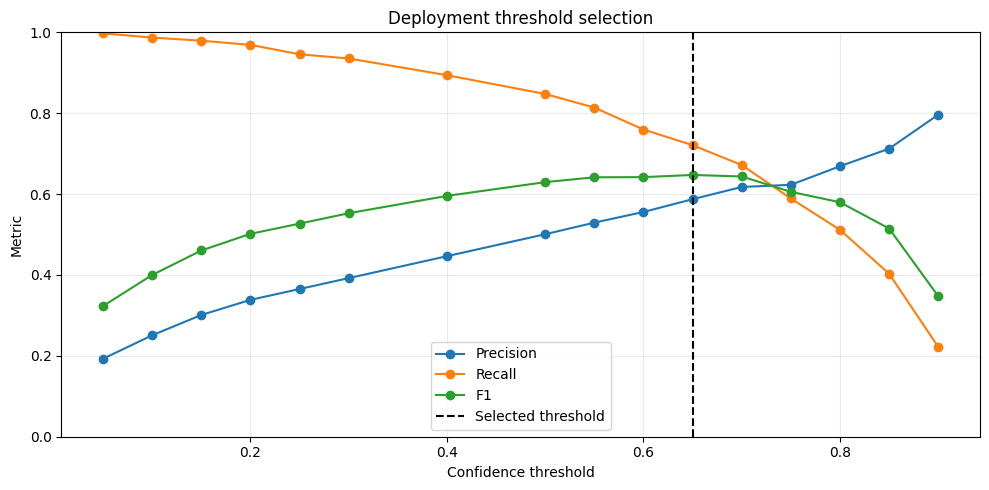

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_dataframe["threshold"],
    threshold_dataframe["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    threshold_dataframe["threshold"],
    threshold_dataframe["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_dataframe["threshold"],
    threshold_dataframe["f1"],
    marker="o",
    label="F1",
)

plt.axvline(
    BEST_CONFIDENCE_THRESHOLD,
    color="black",
    linestyle="--",
    label=(
        "Selected threshold"
    ),
)

plt.xlabel("Confidence threshold")
plt.ylabel("Metric")
plt.ylim(0, 1)
plt.title("Deployment threshold selection")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Per-class and Failure Analysis

**Per-class metrics**

In [17]:
final_evaluation = evaluate_threshold(
    confidence_threshold=(BEST_CONFIDENCE_THRESHOLD),
    iou_threshold=0.50,
)

per_class_rows = []
for class_id, statistics in (final_evaluation["per_class"].items()):
    tp = statistics["tp"]
    fp = statistics["fp"]
    fn = statistics["fn"]
    
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1_score = safe_divide(2 * precision * recall, precision + recall)
    
    per_class_rows.append({
        "class_id": class_id,
        "class_name": model.names[class_id],
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1_score,
    })

per_class_dataframe = pd.DataFrame(per_class_rows)
display(per_class_dataframe.round(4))

,class_id,class_name,tp,fp,fn,precision,recall,f1
0,0,D00,159,103,61,0.6069,0.7227,0.6598
1,1,D10,54,44,33,0.5510,0.6207,0.5838
2,2,D20,51,41,12,0.5543,0.8095,0.6581
3,3,D40,15,8,2,0.6522,0.8824,0.7500


In [18]:
per_class_dataframe.to_csv(
    OUTPUT_ROOT
    / "per_class_operating_metrics.csv",
    index=False,
)

**Failure category counts**

In [ ]:
failure_reason_counts = Counter()

for matching in final_evaluation["details_by_stem"].values():
    for prediction in matching["prediction_details"]:
        if prediction["status"] == "FP":
            failure_reason_counts[prediction["reason"]] += 1


for reason, count in (failure_reason_counts.most_common()):
    print(f"{reason:<20}: {count}")

wrong_class         : 73
duplicate           : 63
poor_localization   : 39
background_fp       : 21


**Rank worst validation images**

In [21]:
error_dataframe = pd.DataFrame(final_evaluation["image_rows"]).sort_values(
    by=[
        "total_errors",
        "fn",
        "fp",
    ],
    ascending=False
)

error_dataframe.to_csv(OUTPUT_ROOT / "per_image_errors.csv", index=False)
display(error_dataframe.head(20))

,stem,tp,fp,fn,total_errors
304,China_MotorBike_001550,0,3,1,4
129,China_MotorBike_000736,0,2,1,3
143,China_MotorBike_000779,0,2,1,3
145,China_MotorBike_000785,0,2,1,3
186,China_MotorBike_000971,0,2,1,3
192,China_MotorBike_001032,0,2,1,3
267,China_MotorBike_001373,0,2,1,3
352,China_MotorBike_001845,0,2,1,3
355,China_MotorBike_001848,0,2,1,3
33,China_MotorBike_000195,1,3,0,3


**Visualize top failure cases**

In [22]:
cache_by_stem = {
    item["stem"]: item for item in prediction_cache
}

number_to_show = min(6, len(error_dataframe))
worst_stems = error_dataframe.head(number_to_show)["stem"].tolist()

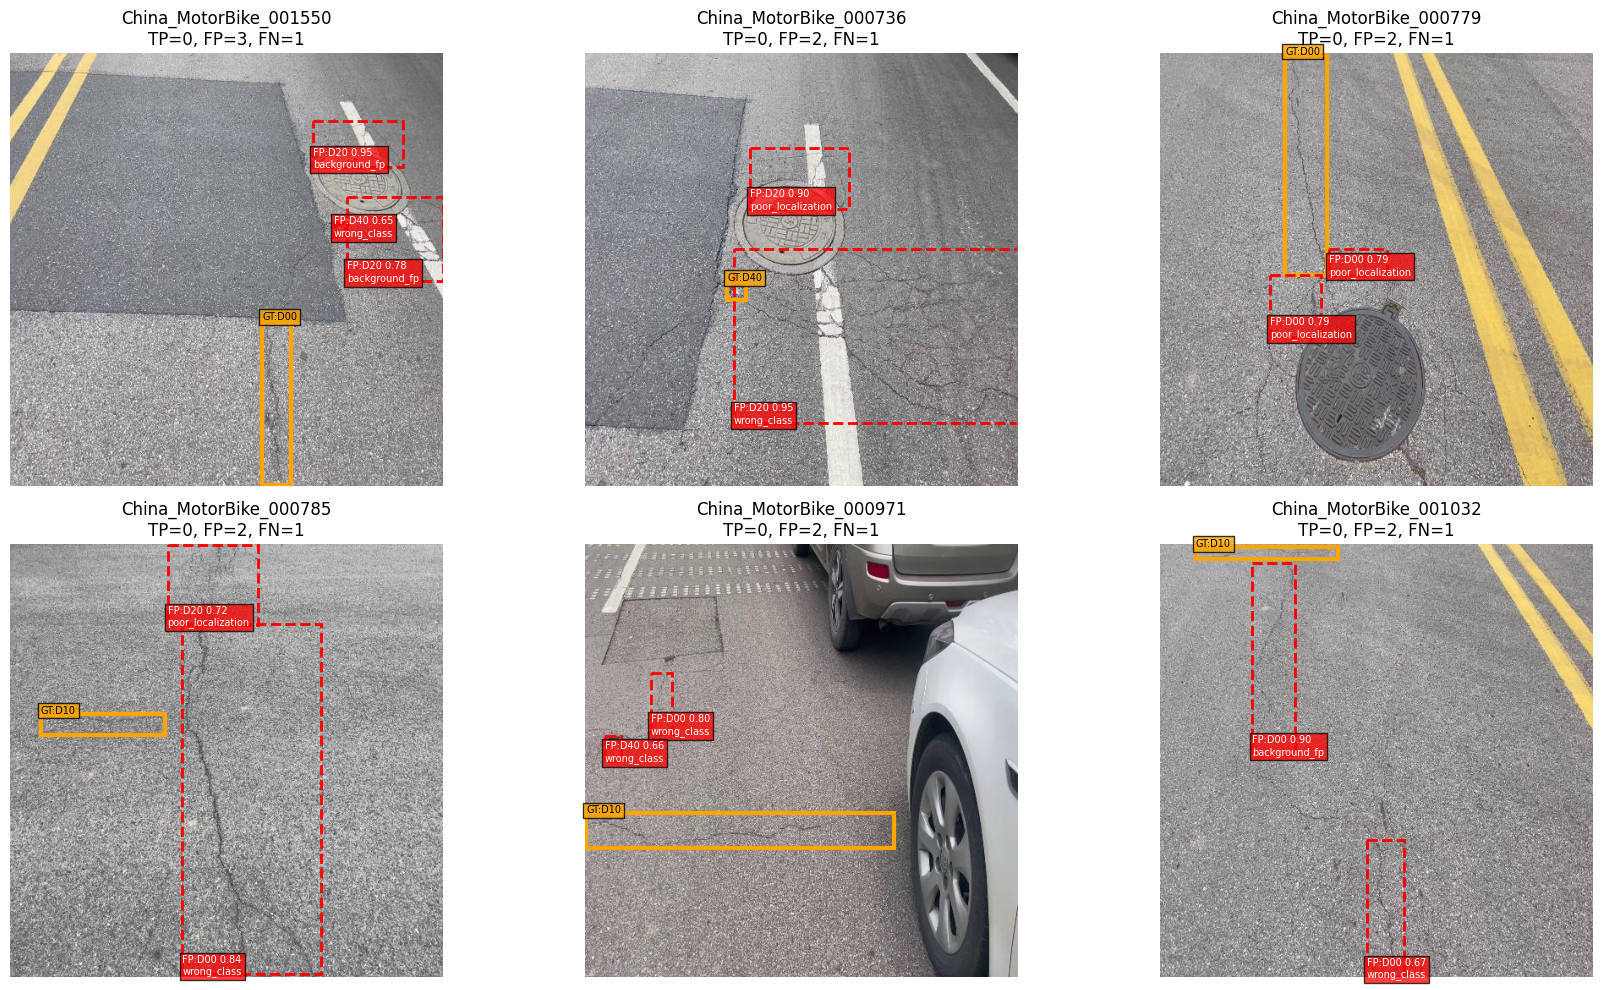

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for axis in axes:
    axis.axis("off")

for axis, stem in zip(axes, worst_stems):
    item = cache_by_stem[stem]
    matching = final_evaluation["details_by_stem"][stem]

    with Image.open(item["image_path"]) as image:
        axis.imshow(image.convert("RGB"))

    for gt_index, (gt_box, gt_class) in enumerate(zip(item["gt_boxes"], item["gt_classes"])):
        x1, y1, x2, y2 = gt_box
        matched = gt_index in matching["matched_ground_truths"]
        color = "lime" if matched else "orange"

        axis.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                edgecolor=color,
                linewidth=3,
            )
        )

        axis.text(
            x1,
            y1,
            f"GT:{model.names[int(gt_class)]}",
            color="black",
            fontsize=7,
            bbox={"facecolor": color, "alpha": 0.8, "pad": 2},
        )

    for prediction in matching["prediction_details"]:
        x1, y1, x2, y2 = prediction["box"]
        color = "dodgerblue" if prediction["status"] == "TP" else "red"

        axis.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                edgecolor=color,
                linewidth=2,
                linestyle="--",
            )
        )

        label = f"{prediction['status']}:{model.names[prediction['class_id']]} {prediction['confidence']:.2f}"
        if prediction["status"] == "FP":
            label += f"\n{prediction['reason']}"

        axis.text(
            x1,
            y2,
            label,
            color="white",
            fontsize=7,
            bbox={"facecolor": color, "alpha": 0.75, "pad": 2},
        )

    image_row = error_dataframe[error_dataframe["stem"] == stem].iloc[0]
    axis.set_title(f"{stem}\nTP={image_row.tp}, FP={image_row.fp}, FN={image_row.fn}")
    axis.axis("off")

plt.tight_layout()

failure_figure_path = OUTPUT_ROOT / "top_failure_cases.png"
plt.savefig(failure_figure_path, dpi=160, bbox_inches="tight")
plt.show()

### Video Inference

In [24]:
VIDEO_PATH =  OUTPUT_ROOT / "validation_sequence_input.mp4"
frame_width = 960
frame_height = 540
frames_per_second = 5

video_writer = cv2.VideoWriter(
    str(VIDEO_PATH), cv2.VideoWriter_fourcc(*"mp4v"),
    frames_per_second,(frame_width,frame_height,))

demo_images = val_images[:min(60, len(val_images))]

for image_path in demo_images:
    frame = cv2.imread(str(image_path))
    frame = cv2.resize(frame, (frame_width,frame_height))
    video_writer.write(frame)

video_writer.release()
print("Created pipeline-test video:", VIDEO_PATH)

Created pipeline-test video: /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/validation_sequence_input.mp4


**Video prediction**

In [25]:
video_result_generator = model.predict(
    source=str(VIDEO_PATH),
    imgsz=IMAGE_SIZE,
    conf=BEST_CONFIDENCE_THRESHOLD,
    device=DEVICE,
    stream=True,
    save=True,
    project=str(OUTPUT_ROOT),
    name="video_inference",
    exist_ok=True,
    verbose=False,
)

In [26]:
processed_frames = 0
for _ in video_result_generator:
    processed_frames += 1

print("Processed frames:",processed_frames)
VIDEO_OUTPUT_DIR = Path(model.predictor.save_dir)

video_output_files = [
    path
    for path in VIDEO_OUTPUT_DIR.iterdir()
    if path.suffix.lower()
    in {
        ".mp4",
        ".avi",
        ".mov",
        ".mkv",
    }
]

print("Output directory:", VIDEO_OUTPUT_DIR)
print("Videos:", video_output_files)

Results saved to /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/video_inference
Processed frames: 60
Output directory: /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/video_inference
Videos: [PosixPath('/content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/video_inference/validation_sequence_input.avi')]


### ONNX Export

In [27]:
export_model = YOLO(str(BEST_MODEL_PATH))

exported_onnx_path = (
    export_model.export(
        format="onnx",
        imgsz=IMAGE_SIZE,
        batch=1,
        dynamic=False,
        simplify=True,
        quantize=32,
        device="cpu"
    )
)

ONNX_MODEL_PATH = Path(exported_onnx_path)
print("ONNX model:", ONNX_MODEL_PATH)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Yolo_road2022_dataset/RDD2022_China_MotorBike/runs/yolo26n_rdd2022_baseline/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 10 packages in 306ms
Prepared 2 packages in 50ms
Installed 2 packages in 6ms
 + colorama==0.4.6
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxsli

In [28]:
DEPLOYMENT_DIR = OUTPUT_ROOT / "deployment"
DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)
DEPLOYMENT_ONNX_PATH = DEPLOYMENT_DIR / "rdd2022_yolo26n_fp32.onnx"
 
shutil.copy2(ONNX_MODEL_PATH, DEPLOYMENT_ONNX_PATH)
print("Deployment ONNX:", DEPLOYMENT_ONNX_PATH)

Deployment ONNX: /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/deployment/rdd2022_yolo26n_fp32.onnx


**Load ONNX and test inference**

In [29]:
onnx_model = YOLO(str(DEPLOYMENT_ONNX_PATH))

test_image_path = val_images[0]
onnx_results = onnx_model.predict(
    source=str(test_image_path),
    imgsz=IMAGE_SIZE,
    conf=BEST_CONFIDENCE_THRESHOLD,
    device="cpu",
    rect=False,
    verbose=False,
)

print("ONNX detections:", len(onnx_results[0].boxes))

Loading /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/deployment/rdd2022_yolo26n_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.29.0 with CPUExecutionProvider
ONNX detections: 1


**PyTorch vs ONNX validation parity**

In [30]:
pytorch_validation = model.val(
    data=str(DATA_YAML_PATH),
    imgsz=IMAGE_SIZE,
    batch=8,
    device=DEVICE,
    conf=0.001,
    plots=False,
    verbose=False,
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 84.0±24.4 MB/s, size: 73.4 KB)
val: Scanning /content/drive/MyDrive/Yolo_road2022_dataset/RDD2022_China_MotorBike/val/labels.cache... 387 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 387/387 77.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 10.9it/s 4.5s0.1s
                   all        387        905      0.812      0.828      0.882      0.562
Speed: 1.1ms preprocess, 4.3ms inference, 0.0ms loss, 0.2ms postprocess per image


In [38]:
common_val_kwargs = {
    "data": str(DATA_YAML_PATH),
    "imgsz": IMAGE_SIZE,
    "batch": 1,
    "device": "cpu",
    "conf": 0.001,
    "rect": False,
    "plots": False,
    "verbose": False,
}

pytorch_cpu_model = YOLO(str(BEST_MODEL_PATH))
pytorch_metrics = pytorch_cpu_model.val(**common_val_kwargs)
onnx_metrics = onnx_model.val(**common_val_kwargs)

pytorch_map = float(pytorch_metrics.box.map)
onnx_map = float(onnx_metrics.box.map)
map_difference = pytorch_map - onnx_map

parity_dataframe = pd.DataFrame(
    [
        {
            "format": "PyTorch",
            "mAP50": float(pytorch_metrics.box.map50),
            "mAP75": float(pytorch_metrics.box.map75),
            "mAP50-95": pytorch_map,
        },
        {
            "format": "ONNX FP32",
            "mAP50": float(onnx_metrics.box.map50),
            "mAP75": float(onnx_metrics.box.map75),
            "mAP50-95": onnx_map,
        },
    ]
)

display(parity_dataframe.round(5))
print("mAP50-95 Difference (PyTorch - ONNX):", round(map_difference , 6))

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 96.4±30.8 MB/s, size: 84.1 KB)
val: Scanning /content/drive/MyDrive/Yolo_road2022_dataset/RDD2022_China_MotorBike/val/labels.cache... 387 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 387/387 108.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 387/387 8.5it/s 45.4s0.1ss
                   all        387        905      0.831      0.805      0.873      0.539
Speed: 1.5ms preprocess, 104.9ms inference, 0.0ms loss, 0.1ms postprocess per image
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Loading /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/deployment/rdd2022_yolo26n_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.29.0 wi

,format,mAP50,mAP75,mAP50-95
0,PyTorch,0.87316,0.58638,0.53878
1,ONNX FP32,0.87316,0.58638,0.53878


mAP50-95 Difference (PyTorch - ONNX): 0.0


In [39]:
if abs(map_difference) > 0.02:
    print(
        "WARNING: ONNX accuracy difference "
        "is larger than expected."
    )
else:
    print("ONNX accuracy parity looks acceptable.")

ONNX accuracy parity looks acceptable.


In [33]:
def benchmark_model(
    benchmark_model,
    source,
    device,
    number_of_runs=30,
    warmup_runs=5,
):
    for _ in range(warmup_runs):
        benchmark_model.predict(
            source=source,
            imgsz=IMAGE_SIZE,
            conf=BEST_CONFIDENCE_THRESHOLD,
            device=device,
            rect=False,
            save=False,
            verbose=False,
        )

    if torch.cuda.is_available() and device != "cpu":
        torch.cuda.synchronize()

    latency_values = []

    for _ in range(number_of_runs):
        start_time = time.perf_counter()

        benchmark_model.predict(
            source=source,
            imgsz=IMAGE_SIZE,
            conf=BEST_CONFIDENCE_THRESHOLD,
            device=device,
            rect=False,
            save=False,
            verbose=False,
        )

        if torch.cuda.is_available() and device != "cpu":
            torch.cuda.synchronize()

        latency_ms = (time.perf_counter() - start_time) * 1000
        latency_values.append(latency_ms)

    latency_values = np.asarray(latency_values, dtype=np.float32)
    mean_latency = float(latency_values.mean())

    return {
        "mean_latency_ms": mean_latency,
        "median_latency_ms": float(np.median(latency_values)),
        "p95_latency_ms": float(np.percentile(latency_values, 95)),
        "fps": 1000 / mean_latency if mean_latency > 0 else 0,
    }

In [34]:
benchmark_frame = cv2.imread(str(test_image_path))
if benchmark_frame is None:
    raise RuntimeError("Benchmark image could not be read.")

pytorch_active_benchmark = (
    benchmark_model(model,benchmark_frame, DEVICE)
)

In [35]:
pytorch_cpu_model = YOLO(
    str(BEST_MODEL_PATH)
)

pytorch_cpu_benchmark = (
    benchmark_model(pytorch_cpu_model, benchmark_frame,"cpu")
)

onnx_cpu_benchmark = (
    benchmark_model(onnx_model, benchmark_frame, "cpu")
)

In [36]:
benchmark_dataframe = pd.DataFrame([
    {
        "backend": (f"PyTorch ({DEVICE})"), **pytorch_active_benchmark
    },
    {
        "backend": "PyTorch CPU", **pytorch_cpu_benchmark
    },
    {
        "backend": "ONNX Runtime CPU", **onnx_cpu_benchmark
    },
])

display(benchmark_dataframe.round(3))

,backend,mean_latency_ms,median_latency_ms,p95_latency_ms,fps
0,PyTorch (0),11.243,10.970,13.282,88.947
1,PyTorch CPU,128.832,135.932,148.507,7.762
2,ONNX Runtime CPU,84.051,74.178,115.779,11.898


In [40]:
benchmark_dataframe.to_csv(OUTPUT_ROOT / "latency_benchmark.csv", index=False)

final_report = {
    "best_model": str(BEST_MODEL_PATH),
    "onnx_model": str(DEPLOYMENT_ONNX_PATH),
    "selected_confidence_threshold": BEST_CONFIDENCE_THRESHOLD,
    "matching_iou_threshold": 0.50,
    "operating_point": {
        "tp": int(final_evaluation["tp"]),
        "fp": int(final_evaluation["fp"]),
        "fn": int(final_evaluation["fn"]),
        "precision": float(final_evaluation["precision"]),
        "recall": float(final_evaluation["recall"]),
        "f1": float(final_evaluation["f1"]),
    },
    "failure_categories": dict(failure_reason_counts),
    "pytorch_map50_95": pytorch_map,
    "onnx_map50_95": onnx_map,
    "onnx_map_difference": map_difference,
    "benchmarks": benchmark_dataframe.to_dict(orient="records"),
}

In [41]:
threshold_report_path = OUTPUT_ROOT / "confidence_threshold_sweep.csv"

threshold_dataframe.to_csv(threshold_report_path, index=False)
print("Saved:", threshold_report_path)

Saved: /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/confidence_threshold_sweep.csv


In [42]:
final_report_path = OUTPUT_ROOT / "unit_01_final_report.json"
final_report_path.write_text(json.dumps(final_report, indent=2), encoding="utf-8")

print("Final report:", final_report_path)

required_outputs = [
    threshold_report_path,
    OUTPUT_ROOT / "per_class_operating_metrics.csv",
    OUTPUT_ROOT / "per_image_errors.csv",
    failure_figure_path,
    DEPLOYMENT_ONNX_PATH,
    OUTPUT_ROOT / "latency_benchmark.csv",
    final_report_path,
]

missing_outputs = [path for path in required_outputs if not path.is_file()]

if missing_outputs:
    print("Missing outputs:")
    for path in missing_outputs:
        print("-", path)
    raise RuntimeError("Final block is incomplete.")

print("=" * 60)
print("VISION UNIT 1 — TECHNICAL WORK COMPLETE")
print("=" * 60)

print("Confidence threshold:", BEST_CONFIDENCE_THRESHOLD)
print("Precision:", round(final_evaluation["precision"], 4))
print("Recall:", round(final_evaluation["recall"], 4))
print("F1:", round(final_evaluation["f1"], 4))
print("PyTorch mAP50-95:", round(pytorch_map, 4))
print("ONNX mAP50-95:", round(onnx_map, 4))
print("Final report:", final_report_path)

Final report: /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/unit_01_final_report.json
VISION UNIT 1 — TECHNICAL WORK COMPLETE
Confidence threshold: 0.65
Precision: 0.5874
Recall: 0.7209
F1: 0.6473
PyTorch mAP50-95: 0.5388
ONNX mAP50-95: 0.5388
Final report: /content/drive/MyDrive/Yolo_road2022_dataset/unit_01_final_analysis/unit_01_final_report.json
